# 03 — Inferential Analysis

**Note**: $n=41$ → low statistical power. Results are **exploratory**, not confirmatory.

**Pipeline**:
1. Mann–Whitney U (Wilcoxon Rank Sum) + Cliff's Delta (magnitude per Romano et al., 2006) for 4 subgroup pairs × 13 characteristics × 2 dimensions (importance and priority)
2. Spearman ρ between n_projects/seniority_ordinal and each Likert (with bootstrap CI)
3. Holm–Bonferroni for multiple comparisons
4. Output: `tables/inferential.tex` consolidating significant findings

**Subgroups**:
- Seniors (Mid+Senior, n=20) vs Juniors (Intern+Junior, n=12)
- Data scientists (n=18) vs Developers (n=9)
- More experienced (>3 projects) vs Less experienced (≤3 projects)
- Men (n=24) vs Women (n=8) — bonus, but report with caution

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests

sys.path.insert(0, str(Path.cwd()))
import utils as U

TABLES = U.DATA_PROC / "tables"
df = U.load_anonymized()
print(f"N={len(df)}")

N=41


## 1. Helper: Mann–Whitney + Cliff's Delta

In [2]:
def mwu_delta(g1: pd.Series, g2: pd.Series, n_boot: int = 10_000) -> dict:
    g1 = g1.dropna().astype(float)
    g2 = g2.dropna().astype(float)
    if len(g1) < 2 or len(g2) < 2:
        return {"U": np.nan, "p": np.nan, "delta": np.nan,
                "ci_lo": np.nan, "ci_hi": np.nan, "ci_method": "insufficient",
                "magnitude": "insufficient", "n1": len(g1), "n2": len(g2),
                "med1": np.nan, "med2": np.nan}
    U_stat, p = stats.mannwhitneyu(g1, g2, alternative="two-sided")
    cd = U.cliffs_delta_with_ci(g1, g2, n_resamples=n_boot)
    return {"U": float(U_stat), "p": float(p),
            "delta": cd["delta"], "ci_lo": cd["ci_lo"], "ci_hi": cd["ci_hi"],
            "ci_method": cd["method"], "magnitude": cd["magnitude"],
            "n1": int(len(g1)), "n2": int(len(g2)),
            "med1": float(g1.median()), "med2": float(g2.median())}


## 2. Subgroup comparisons

For each subgroup pair × each Likert (importance and priority).

In [3]:
comparisons = [
    ("Seniors × Juniors",
     df[df["seniority_group"] == "senior"], df[df["seniority_group"] == "junior"]),
    ("Data scientists × Developers",
     df[df["role_group"] == "data_scientist"], df[df["role_group"] == "developer"]),
    (">3 projects × ≤3 projects",
     df[df["n_projects"] > 3], df[df["n_projects"] <= 3]),
    ("Men × Women",
     df[df["gender_norm"] == "male"], df[df["gender_norm"] == "female"]),
]

def collect_tests(comparisons, cols, dim_label):
    rows = []
    for comp_name, g1, g2 in comparisons:
        for col in cols:
            char = col.split("_", 1)[1]
            r = mwu_delta(g1[col], g2[col])
            rows.append({"dim": dim_label, "comparison": comp_name,
                         "characteristic": char, **r})
    return pd.DataFrame(rows)

imp_tests = collect_tests(comparisons, U.IMP_COLS, "importance")
pri_tests = collect_tests(comparisons, U.PRI_COLS, "priority")
tests = pd.concat([imp_tests, pri_tests], ignore_index=True)
print(f"Total tests: {len(tests)}")
tests.head()

Total tests: 104


,dim,comparison,characteristic,U,p,delta,ci_lo,ci_hi,ci_method,magnitude,n1,n2,med1,med2
0,importance,Seniors × Juniors,precision,216.0,0.820453,0.033493,-0.222488,0.311005,bca,negligible,22,19,5.0,5.0
1,importance,Seniors × Juniors,completeness,252.5,0.198492,0.208134,-0.119617,0.502392,bca,small,22,19,5.0,4.0
2,importance,Seniors × Juniors,consistency,247.5,0.222258,0.184211,-0.119617,0.460347,bca,small,22,19,5.0,5.0
3,importance,Seniors × Juniors,credibility,256.5,0.122175,0.227273,-0.055024,0.497608,bca,small,22,19,5.0,5.0
4,importance,Seniors × Juniors,currentness,227.5,0.617618,0.088517,-0.258373,0.413876,bca,negligible,22,19,4.0,4.0


## 3. Holm–Bonferroni correction

Applied **within each comparison-pair × dimension** (avoids over-correcting across unrelated comparisons).

In [4]:
def add_holm(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["p_holm"] = np.nan
    out["sig_raw"] = out["p"] < 0.05
    out["sig_holm"] = False
    for (comp, dim), grp in out.groupby(["comparison", "dim"]):
        valid = grp["p"].notna()
        if valid.sum() == 0:
            continue
        reject, p_adj, _, _ = multipletests(grp.loc[valid, "p"], method="holm")
        idx = grp.loc[valid].index
        out.loc[idx, "p_holm"] = p_adj
        out.loc[idx, "sig_holm"] = reject
    return out

tests = add_holm(tests)
sig_raw = tests[tests["sig_raw"]]
sig_holm = tests[tests["sig_holm"]]
print(f"Significant (raw p<0.05): {len(sig_raw)}")
print(f"Significant after Holm: {len(sig_holm)}")
print("\nLargest effects (|delta| >= 0.33, raw p < 0.05):")
interesting = tests[(tests["sig_raw"]) & (tests["delta"].abs() >= 0.33)].sort_values("delta", key=abs, ascending=False)
print(interesting[["dim", "comparison", "characteristic", "med1", "med2", "delta", "magnitude", "p", "p_holm"]].to_string(index=False))

Significant (raw p<0.05): 14
Significant after Holm: 4

Largest effects (|delta| >= 0.33, raw p < 0.05):
       dim                   comparison characteristic  med1  med2     delta magnitude        p   p_holm
  priority    >3 projects × ≤3 projects     efficiency   3.0   4.5 -0.623188     large 0.000434 0.005648
importance    >3 projects × ≤3 projects     efficiency   4.0   5.0 -0.555556     large 0.001164 0.015136
  priority    >3 projects × ≤3 projects recoverability   3.0   4.5 -0.550725     large 0.001779 0.021346
  priority Data scientists × Developers    currentness   4.0   3.0  0.512397     large 0.014187 0.184432
  priority    >3 projects × ≤3 projects   availability   4.0   4.5 -0.490338     large 0.005318 0.053176
  priority    >3 projects × ≤3 projects    reliability   4.0   5.0 -0.487923     large 0.003413 0.037547
  priority    >3 projects × ≤3 projects     compliance   3.0   5.0 -0.478261     large 0.005873 0.053176
importance    >3 projects × ≤3 projects recoverability 

## 4. Spearman ρ — n_projects × Likerts; seniority × Likerts

Correlation ρ by characteristic between n_projects/seniority_ordinal and each Likert (Q11/Q13).

- **Paired bootstrap 95% CI** (BCa, 10k resamples; fallback to percentile if BCa degenerates).
- We report ρ [95% CI] in addition to p-value — more informative given N=41.


In [5]:
def spearman_rows(predictor: str, cols: list[str], dim: str,
                  n_boot: int = 10_000) -> pd.DataFrame:
    rows = []
    for col in cols:
        res = U.spearman_with_ci(df[predictor], df[col], n_resamples=n_boot)
        if res["method"] == "insufficient":
            continue
        rows.append({"dim": dim, "predictor": predictor,
                     "characteristic": col.split("_", 1)[1],
                     **res})
    return pd.DataFrame(rows)

spear = pd.concat([
    spearman_rows("n_projects", U.IMP_COLS, "importance"),
    spearman_rows("n_projects", U.PRI_COLS, "priority"),
    spearman_rows("seniority_ordinal", U.IMP_COLS, "importance"),
    spearman_rows("seniority_ordinal", U.PRI_COLS, "priority"),
], ignore_index=True)
spear["sig_raw"] = spear["p"] < 0.05
spear["ci_excludes_zero"] = (spear["ci_lo"] > 0) | (spear["ci_hi"] < 0)

print(f"Spearman: {len(spear)} tests")
print(f"Significant (raw p<0.05): {spear['sig_raw'].sum()}")
print(f"95% CI excludes zero:     {spear['ci_excludes_zero'].sum()}")
print(f"CI methods: {spear['method'].value_counts().to_dict()}")
print()
disp_cols = ["dim", "predictor", "characteristic", "n", "rho", "ci_lo", "ci_hi", "p", "method"]
print("Top correlations |rho|:")
print(spear.sort_values("rho", key=abs, ascending=False).head(10)[disp_cols].to_string(index=False))
print()
print("Significant (raw):")
if spear["sig_raw"].any():
    print(spear[spear["sig_raw"]].sort_values("p")[disp_cols].to_string(index=False))
else:
    print("  (none)")


Spearman: 52 tests
Significant (raw p<0.05): 9
95% CI excludes zero:     8
CI methods: {'bca': 52}

Top correlations |rho|:
       dim         predictor    characteristic  n       rho     ci_lo     ci_hi        p method
  priority        n_projects        efficiency 41 -0.590131 -0.772794 -0.324281 0.000049    bca
  priority        n_projects      availability 41 -0.412749 -0.648552 -0.096502 0.007321    bca
  priority        n_projects    recoverability 41 -0.405238 -0.649973 -0.074678 0.008580    bca
  priority seniority_ordinal        efficiency 41 -0.389885 -0.616959 -0.080499 0.011739    bca
  priority        n_projects       reliability 41 -0.380145 -0.613697 -0.067984 0.014220    bca
importance        n_projects        efficiency 41 -0.372267 -0.627972 -0.016112 0.016539    bca
  priority        n_projects        compliance 41 -0.344618 -0.618048  0.003187 0.027351    bca
importance        n_projects    recoverability 41 -0.331991 -0.587121 -0.023250 0.033956    bca
  priority s

## 5. Heatmap subgroups × characteristics — % high + delta vs Total

We already have the simple heatmap in notebook 02. Here we derive a figure with differences (subgroup − total) to highlight where subgroups diverge.

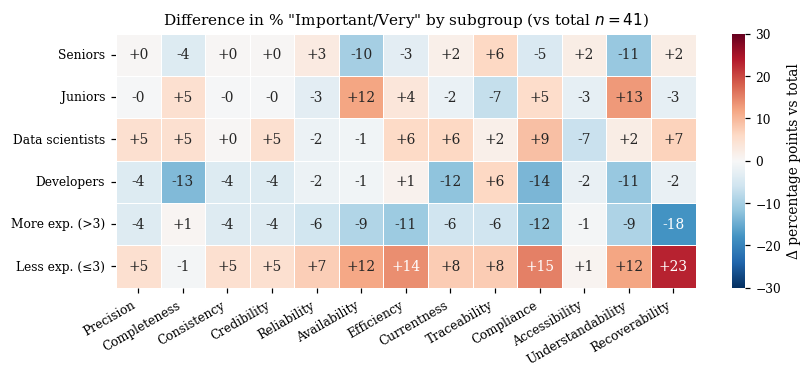

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
U.setup_matplotlib()

def pct_top2(g, col):
    s = g[col].dropna()
    return (s >= 4).sum() / len(s) * 100 if len(s) else np.nan

groups_def = {
    "Seniors": df[df["seniority_group"] == "senior"],
    "Juniors": df[df["seniority_group"] == "junior"],
    "Data scientists": df[df["role_group"] == "data_scientist"],
    "Developers": df[df["role_group"] == "developer"],
    "More exp. (>3)": df[df["n_projects"] > 3],
    "Less exp. (≤3)": df[df["n_projects"] <= 3],
}
total_imp = pd.Series({c: pct_top2(df, f"imp_{c}") for c in U.CHARACTERISTICS_PT.keys()})
diffs = pd.DataFrame({
    label: [pct_top2(g, f"imp_{c}") - total_imp[c] for c in U.CHARACTERISTICS_PT.keys()]
    for label, g in groups_def.items()
}, index=[U.CHARACTERISTICS_PT[c] for c in U.CHARACTERISTICS_PT.keys()]).T
diffs = diffs[total_imp.sort_values(ascending=False).rename(lambda c: U.CHARACTERISTICS_PT[c]).index]

fig, ax = plt.subplots(figsize=(8.5, 3.0))
sns.heatmap(diffs, annot=True, fmt="+.0f", cmap="RdBu_r", center=0,
            cbar_kws={"label": "Δ percentage points vs total"},
            linewidths=0.4, linecolor="white", ax=ax, vmin=-30, vmax=30)
ax.set_title("Difference in % \"Important/Very\" by subgroup (vs total $n=41$)")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
U.save_fig(fig, "heatmap_subgroup_diff")
plt.show()

## 6. Table 3 — inferential tests

Includes **only** comparisons with p<0.05 or |delta|>=0.33 + small/medium/large magnitude. Maintains transparency: report everything in the replication package, cite only the relevant in the paper.

In [7]:
tests.to_csv(TABLES / "inferential_full.csv", index=False)
spear.to_csv(TABLES / "spearman_full.csv", index=False)
print(f"[saved] tables/inferential_full.csv ({len(tests)} rows)")
print(f"[saved] tables/spearman_full.csv ({len(spear)} rows)")

# LaTeX table only with non-negligible findings (|delta|>=0.33 OR sig)
report = tests[(tests["sig_raw"]) | (tests["delta"].abs() >= 0.33)].copy()
report = report.sort_values(["comparison", "dim", "p"]).reset_index(drop=True)

def format_p(p):
    if pd.isna(p):
        return "--"
    if p < 0.001:
        return "<0.001"
    return f"{p:.3f}"

lines = [
    "\\begin{table*}[t]",
    "\\caption{Exploratory subgroup comparisons. Mann–Whitney $U$, Cliff's $\\delta$ (Romano et al., 2006), $p_{\\text{Holm}}$ corrected by comparison pair. Only rows with $p<0.05$ or $|\\delta|\\geq 0.33$ shown.}",
    "\\label{tab:inferential}",
    "\\centering",
    "\\small",
    "\\begin{tabular}{llllrrlrll}",
    "\\toprule",
    "\\textbf{Comparison} & \\textbf{Dim.} & \\textbf{Characteristic} & \\textbf{Med.} & $\\delta$ & \\textbf{IC$_{95}$} & \\textbf{Mag.} & $U$ & $p$ & $p_{\\text{Holm}}$ \\\\",
    "\\midrule",
]
for _, r in report.iterrows():
    char = U.CHARACTERISTICS_PT.get(r["characteristic"], r["characteristic"])
    med_str = f"{r['med1']:.0f} vs {r['med2']:.0f}"
    lines.append(
        f"{r['comparison']} & {r['dim']} & {char} & {med_str} & {r['delta']:+.2f} & [{r['ci_lo']:+.2f},{r['ci_hi']:+.2f}] & {r['magnitude']} & {r['U']:.0f} & {format_p(r['p'])} & {format_p(r['p_holm'])} \\\\"
    )
lines.extend(["\\bottomrule", "\\end{tabular}", "\\end{table*}"])
(TABLES / "inferential.tex").write_text("\n".join(lines))
print(f"[saved] tables/inferential.tex ({len(report)} rows in paper)")
report[["comparison", "dim", "characteristic", "med1", "med2", "delta", "magnitude", "p", "p_holm"]]

[saved] tables/inferential_full.csv (104 rows)
[saved] tables/spearman_full.csv (52 rows)
[saved] tables/inferential.tex (21 rows in paper)


,comparison,dim,characteristic,med1,med2,delta,magnitude,p,p_holm
0,>3 projects × ≤3 projects,importance,efficiency,4.0,5.0,-0.555556,large,0.001164,0.015136
1,>3 projects × ≤3 projects,importance,recoverability,3.0,5.0,-0.468599,medium,0.006522,0.078268
2,>3 projects × ≤3 projects,importance,reliability,4.0,5.0,-0.376812,medium,0.016438,0.180817
3,>3 projects × ≤3 projects,priority,efficiency,3.0,4.5,-0.623188,large,0.000434,0.005648
4,>3 projects × ≤3 projects,priority,recoverability,3.0,4.5,-0.550725,large,0.001779,0.021346
5,>3 projects × ≤3 projects,priority,reliability,4.0,5.0,-0.487923,large,0.003413,0.037547
6,>3 projects × ≤3 projects,priority,availability,4.0,4.5,-0.490338,large,0.005318,0.053176
7,>3 projects × ≤3 projects,priority,compliance,3.0,5.0,-0.478261,large,0.005873,0.053176
8,>3 projects × ≤3 projects,priority,accessibility,3.0,4.0,-0.357488,medium,0.041938,0.335504
9,>3 projects × ≤3 projects,priority,understandability,4.0,4.0,-0.338164,medium,0.052808,0.369655


## 7. Inferential summary — plug-and-play text for the paper

In [8]:
# Concise text findings
report_text = []
if len(sig_holm):
    for _, r in sig_holm.iterrows():
        char = U.CHARACTERISTICS_PT.get(r["characteristic"], r["characteristic"])
        report_text.append(
            f"[{r['comparison']}, {r['dim']}] {char}: "
            f"$\\delta$={r['delta']:+.2f} ({r['magnitude']}), p={r['p']:.3f}, p_Holm={r['p_holm']:.3f}."
        )
else:
    report_text.append("No comparison survived Holm correction. Report as exploratory.")

for _, r in interesting.iterrows():
    if not r['sig_holm']:
        char = U.CHARACTERISTICS_PT.get(r["characteristic"], r["characteristic"])
        report_text.append(
            f"[{r['comparison']}, {r['dim']}] {char}: "
            f"$\\delta$={r['delta']:+.2f} ({r['magnitude']}), p={r['p']:.3f} raw (did not survive Holm) — report as a trend."
        )

for line in report_text:
    print(line)

(TABLES / "inferential_findings.txt").write_text("\n".join(report_text))
print("\n[saved] tables/inferential_findings.txt")

[>3 projects × ≤3 projects, importance] Efficiency: $\delta$=-0.56 (large), p=0.001, p_Holm=0.015.
[>3 projects × ≤3 projects, priority] Reliability: $\delta$=-0.49 (large), p=0.003, p_Holm=0.038.
[>3 projects × ≤3 projects, priority] Efficiency: $\delta$=-0.62 (large), p=0.000, p_Holm=0.006.
[>3 projects × ≤3 projects, priority] Recoverability: $\delta$=-0.55 (large), p=0.002, p_Holm=0.021.
[Data scientists × Developers, priority] Currentness: $\delta$=+0.51 (large), p=0.014 raw (did not survive Holm) — report as a trend.
[>3 projects × ≤3 projects, priority] Availability: $\delta$=-0.49 (large), p=0.005 raw (did not survive Holm) — report as a trend.
[>3 projects × ≤3 projects, priority] Compliance: $\delta$=-0.48 (large), p=0.006 raw (did not survive Holm) — report as a trend.
[>3 projects × ≤3 projects, importance] Recoverability: $\delta$=-0.47 (medium), p=0.007 raw (did not survive Holm) — report as a trend.
[Men × Women, priority] Credibility: $\delta$=-0.45 (medium), p=0.012 ra

## 8. Paired Wilcoxon — Importance × Priority

Within-subject: for each characteristic, tests whether respondents assign different scores in Q11 (importance) and Q13 (priority). Formalizes the descriptive gap from Section 6 of notebook 02.

- Effect size: matched-pairs rank-biserial *r* (Kerby 2014); |r| < 0.1 negligible, < 0.3 small, < 0.5 medium, ≥ 0.5 large.
- Holm–Bonferroni within the family of the 13 characteristics.
-  ⇒ importance typically above priority (i.e., there is a gap).


In [9]:
rows = []
for col_imp, col_pri in zip(U.IMP_COLS, U.PRI_COLS):
    char = col_imp.split("_", 1)[1]
    res = U.wilcoxon_paired(df[col_imp], df[col_pri])
    rows.append({"characteristic": char,
                 "med_imp": float(df[col_imp].median()),
                 "med_pri": float(df[col_pri].median()),
                 **res})
paired = pd.DataFrame(rows)

valid = paired["p"].notna()
if valid.sum():
    reject, p_adj, _, _ = multipletests(paired.loc[valid, "p"], method="holm")
    paired["p_holm"] = float("nan")
    paired.loc[valid, "p_holm"] = p_adj
    paired["sig_holm"] = False
    paired.loc[valid, "sig_holm"] = reject
else:
    paired["p_holm"] = float("nan")
    paired["sig_holm"] = False
paired["sig_raw"] = paired["p"] < 0.05

paired_disp = paired[["characteristic", "n", "med_imp", "med_pri", "med_diff",
                      "r_rb", "magnitude", "W", "p", "p_holm", "sig_holm"]]
print(f"Significant paired (raw p<0.05): {paired['sig_raw'].sum()}")
print(f"Significant paired after Holm:   {paired['sig_holm'].sum()}")
print()
print(paired_disp.sort_values("r_rb", key=abs, ascending=False).to_string(index=False))


Significant paired (raw p<0.05): 7
Significant paired after Holm:   2

   characteristic  n  med_imp  med_pri  med_diff     r_rb magnitude    W        p   p_holm  sig_holm
     availability 41      5.0      4.0       0.0 0.816993     large 14.0 0.001766 0.022962      True
      consistency 41      5.0      5.0       0.0 0.666667     large 11.0 0.032509 0.227566     False
      currentness 41      4.0      4.0       0.0 0.661538     large 55.0 0.001811 0.022962      True
     completeness 41      5.0      4.0       0.0 0.625000     large 22.5 0.018422 0.183726     False
       efficiency 41      4.0      4.0       0.0 0.619048     large 40.0 0.011170 0.122868     False
   recoverability 41      4.0      4.0       0.0 0.607843     large 30.0 0.018373 0.183726     False
      credibility 41      5.0      5.0       0.0 0.533333     large 10.5 0.140773 0.570843     False
     traceability 41      4.0      4.0       0.0 0.523810     large 50.0 0.021810 0.183726     False
      reliability 41

In [10]:
# Save auxiliary table for inspection / future use in the paper
out_path = U.DATA_PROC / "tables" / "wilcoxon_imp_vs_pri.csv"
out_path.parent.mkdir(parents=True, exist_ok=True)
paired_disp.to_csv(out_path, index=False)
print(f"-> {out_path.relative_to(U.ROOT)}")


-> data/processed/tables/wilcoxon_imp_vs_pri.csv


## 9. Friedman + Nemenyi — global ranking of the 13 characteristics

Within-subject: each respondent ranks the 13 characteristics. Friedman tests whether there are systematic rank differences; Nemenyi is the standard non-parametric post-hoc for treatment pairs after Friedman (Demšar 2006).

Applied separately to Q11 (importance) and Q13 (priority). Rows with any NA are dropped (within-subject requires all treatments per subject).


In [11]:
import scikit_posthocs as sp

def friedman_block(cols: list[str], dim_name: str) -> dict:
    block = df[cols].dropna()
    n_subj = len(block)
    if n_subj < 5:
        return {"dim": dim_name, "n": n_subj, "chi2": float("nan"),
                "p": float("nan"), "df": len(cols) - 1, "nemenyi": None,
                "mean_ranks": None}
    chi2, p = stats.friedmanchisquare(*[block[c].values for c in cols])
    # Nemenyi post-hoc: K×K p-value matrix. Accepts wide form: rows=subjects, cols=treatments.
    nemenyi = sp.posthoc_nemenyi_friedman(block.to_numpy())
    nemenyi.index = [c.split("_", 1)[1] for c in cols]
    nemenyi.columns = nemenyi.index
    # Mean ranks (Friedman ranks within each subject, then averaged across subjects)
    ranks = block.rank(axis=1, method="average")
    mean_ranks = ranks.mean().sort_values()
    mean_ranks.index = [c.split("_", 1)[1] for c in cols]
    return {"dim": dim_name, "n": n_subj, "chi2": float(chi2), "p": float(p),
            "df": len(cols) - 1, "nemenyi": nemenyi, "mean_ranks": mean_ranks}

friedman_imp = friedman_block(U.IMP_COLS, "importance")
friedman_pri = friedman_block(U.PRI_COLS, "priority")

for r in (friedman_imp, friedman_pri):
    print(f"=== Friedman — {r['dim']} (complete N = {r['n']}) ===")
    print(f"  chi² = {r['chi2']:.2f}  df = {r['df']}  p = {r['p']:.6f}")
    print(f"  Mean ranks (smaller = better-ranked):")
    for char, rk in r["mean_ranks"].items():
        print(f"    {char:<20s} {rk:.2f}")
    print()


=== Friedman — importance (complete N = 41) ===
  chi² = 85.53  df = 12  p = 0.000000
  Mean ranks (smaller = better-ranked):
    precision            5.35
    completeness         5.40
    consistency          5.84
    credibility          6.09
    currentness          6.22
    accessibility        6.27
    compliance           6.30
    reliability          7.37
    efficiency           7.88
    traceability         8.27
    understandability    8.48
    availability         8.56
    recoverability       8.98

=== Friedman — priority (complete N = 41) ===
  chi² = 91.10  df = 12  p = 0.000000
  Mean ranks (smaller = better-ranked):
    precision            5.44
    completeness         5.45
    consistency          5.65
    credibility          5.76
    currentness          5.99
    accessibility        6.23
    compliance           6.80
    reliability          6.83
    efficiency           7.67
    traceability         8.54
    understandability    8.60
    availability         9.01

In [12]:
# Significant Nemenyi pairs (p < 0.05) by dimension
def list_significant_pairs(result, alpha: float = 0.05) -> pd.DataFrame:
    if result["nemenyi"] is None:
        return pd.DataFrame()
    nem = result["nemenyi"]
    rows = []
    chars = list(nem.index)
    for i, a in enumerate(chars):
        for b in chars[i + 1:]:
            p = float(nem.loc[a, b])
            if p < alpha:
                rows.append({"dim": result["dim"], "a": a, "b": b,
                             "rank_a": float(result["mean_ranks"][a]),
                             "rank_b": float(result["mean_ranks"][b]),
                             "p": p})
    return pd.DataFrame(rows).sort_values("p")

sig_imp = list_significant_pairs(friedman_imp)
sig_pri = list_significant_pairs(friedman_pri)

print(f"Nemenyi significant pairs (p<0.05) — importance: {len(sig_imp)}")
if len(sig_imp):
    print(sig_imp.head(20).to_string(index=False))
print()
print(f"Nemenyi significant pairs (p<0.05) — priority: {len(sig_pri)}")
if len(sig_pri):
    print(sig_pri.head(20).to_string(index=False))


Nemenyi significant pairs (p<0.05) — importance: 10
       dim             a                 b   rank_a   rank_b        p
importance     precision understandability 5.353659 8.475610 0.001786
importance     precision     accessibility 5.353659 6.268293 0.002270
importance   credibility understandability 6.085366 8.475610 0.012150
importance   credibility     accessibility 6.085366 6.268293 0.014937
importance     precision      traceability 5.353659 8.268293 0.016536
importance   consistency understandability 5.841463 8.475610 0.017392
importance   consistency     accessibility 5.841463 6.268293 0.021223
importance   reliability understandability 7.365854 8.475610 0.039331
importance     precision       currentness 5.353659 6.219512 0.043065
importance accessibility       reliability 6.268293 7.365854 0.047101

Nemenyi significant pairs (p<0.05) — priority: 16
     dim             a                 b   rank_a   rank_b        p
priority     precision       currentness 5.439024 5.987805 

In [13]:
# Save Nemenyi matrices and mean ranks
for r, name in [(friedman_imp, "imp"), (friedman_pri, "pri")]:
    if r["nemenyi"] is not None:
        r["nemenyi"].to_csv(TABLES / f"nemenyi_{name}.csv")
        r["mean_ranks"].to_csv(TABLES / f"friedman_ranks_{name}.csv", header=["mean_rank"])
        print(f"-> tables/nemenyi_{name}.csv, tables/friedman_ranks_{name}.csv")


-> tables/nemenyi_imp.csv, tables/friedman_ranks_imp.csv
-> tables/nemenyi_pri.csv, tables/friedman_ranks_pri.csv
